# Algoritmos de optimización - Seminario

**Nombre y apellidos:**  
Francis Arthur Poldark Palomino Marino  
Cesar Jose Ortiz Sabogal

**URL:** `https://github.com/FPalomino-gif/Algoritmos-de-optimizacion-seminario`

**Problema seleccionado:**

> **3. Combinar cifras y operaciones**

## Descripción del problema

Disponemos de las nueve cifras del 1 al 9, excluyendo el cero, y de los cuatro signos básicos de las operaciones fundamentales: suma (`+`), resta (`-`), multiplicación (`*`) y división (`/`). Debemos combinarlos alternativamente, sin repetir ninguna cifra ni ningún operador, para obtener una cantidad dada. Un ejemplo para obtener el valor 4 es:

`4 + 2 - 6 / 3 * 1 = 4`

El trabajo debe encontrar todos los resultados enteros posibles, determinar sus valores mínimo y máximo y comprobar si pueden obtenerse todos los enteros comprendidos entre ambos.

### Interpretación adoptada

1. Se utilizan **exactamente los cuatro operadores**, una vez cada uno; por ello, cada expresión contiene **cinco cifras distintas**.
2. La expresión tiene la estructura `cifra-operador-cifra-operador-cifra-operador-cifra-operador-cifra`.
3. No se permiten paréntesis, concatenación de cifras ni operadores adicionales.
4. Se aplica la precedencia aritmética habitual: multiplicación y división antes que suma y resta; a igual precedencia, evaluación de izquierda a derecha.
5. La función `eval()` es una posibilidad indicada en el enunciado, pero no es obligatoria. En el algoritmo principal se utiliza aritmética racional exacta para evitar errores de redondeo.

`(*) La respuesta es obligatoria según la plantilla oficial.`


In [1]:
# Librerías y configuración general
from itertools import permutations
from fractions import Fraction
from collections import Counter
import math
import random
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

CIFRAS = tuple(range(1, 10))
OPERADORES = ('+', '-', '*', '/')


def construir_expresion(cifras, operadores):
    """Construye la cadena alternada cifra-operador-cifra."""
    partes = [str(cifras[0])]
    for operador, cifra in zip(operadores, cifras[1:]):
        partes.extend([operador, str(cifra)])
    return ''.join(partes)


def evaluar_exacta(cifras, operadores):
    """Evalúa respetando la precedencia estándar mediante Fraction.

    `acumulado` contiene los términos ya cerrados por + o -.
    `termino` contiene la cadena actual de multiplicaciones/divisiones,
    incluyendo su signo.
    """
    acumulado = Fraction(0, 1)
    termino = Fraction(cifras[0], 1)

    for operador, cifra in zip(operadores, cifras[1:]):
        if operador == '+':
            acumulado += termino
            termino = Fraction(cifra, 1)
        elif operador == '-':
            acumulado += termino
            termino = Fraction(-cifra, 1)
        elif operador == '*':
            termino *= cifra
        elif operador == '/':
            termino /= cifra
        else:
            raise ValueError(f'Operador no válido: {operador}')

    return acumulado + termino


def evaluar_cadena_exacta(expresion):
    """Convierte una expresión generada internamente a cifras y operadores."""
    tokens = re.findall(r'\d+|[+\-*/]', expresion)
    cifras = tuple(int(tokens[i]) for i in range(0, len(tokens), 2))
    operadores = tuple(tokens[i] for i in range(1, len(tokens), 2))
    return evaluar_exacta(cifras, operadores)


# Demostración de la nota del enunciado: eval() es posible, no obligatorio.
expresion_demo = '4+2-6/3*1'
print('Evaluación con eval():', eval(expresion_demo))
print('Evaluación exacta:     ', evaluar_cadena_exacta(expresion_demo))
print('Cifras disponibles:    ', CIFRAS)
print('Operadores disponibles:', OPERADORES)


Evaluación con eval(): 4.0
Evaluación exacta:      4
Cifras disponibles:     (1, 2, 3, 4, 5, 6, 7, 8, 9)
Operadores disponibles: ('+', '-', '*', '/')


## 1. Espacio de soluciones

**(*) ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?**  
**¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?**


### Respuesta

Se mantiene como estructura básica la alternancia de cinco posiciones de cifras y cuatro posiciones de operadores.

**Sin aplicar las restricciones de no repetición:**

- Cada una de las cinco posiciones numéricas puede tomar 9 valores.
- Cada una de las cuatro posiciones de operador puede tomar 4 valores.

Por tanto:

`9^5 · 4^4 = 15 116 544` expresiones.

**Aplicando todas las restricciones:**

- Las cinco cifras son una variación sin repetición de 9 elementos: `P(9,5) = 9·8·7·6·5 = 15 120`.
- Los cuatro operadores se utilizan una vez: `4! = 24` órdenes.

Por tanto:

`P(9,5) · 4! = 15 120 · 24 = 362 880` expresiones factibles.

El orden importa tanto en las cifras como en los operadores porque, en general, cambiarlo modifica el resultado.


In [2]:
# Verificación computacional de los tamaños del espacio de soluciones
sin_restricciones = len(CIFRAS) ** 5 * len(OPERADORES) ** 4
con_restricciones = math.perm(len(CIFRAS), 5) * math.factorial(len(OPERADORES))

print(f'Sin restricciones de repetición: {sin_restricciones:,}')
print(f'Con todas las restricciones:     {con_restricciones:,}')
assert sin_restricciones == 15_116_544
assert con_restricciones == 362_880


Sin restricciones de repetición: 15,116,544
Con todas las restricciones:     362,880


## 2. Modelo para el espacio de soluciones

**(*) ¿Cuál es la estructura de datos que mejor se adapta al problema? Argumente la respuesta.**  
*(Es posible elegir una estructura al principio y posteriormente justificar la necesidad de cambiarla.)*


### Respuesta

Se utilizan varias estructuras, cada una con una responsabilidad concreta:

- **Tuplas** para representar las cifras y los operadores de una expresión. Son inmutables, compactas y apropiadas como claves de diccionario.
- **Generadores de permutaciones** de `itertools` para la fuerza bruta. No es una exigencia del enunciado, sino una elección clara y directa para recorrer elementos sin repetición.
- **Diccionarios** para asociar cada resultado entero con una expresión representativa y para memorizar estados equivalentes en el algoritmo mejorado.
- **Conjuntos y `Counter`** para comprobar valores distintos y contar cuántas expresiones producen cada entero.
- **`Fraction`** para representar resultados racionales exactamente, evitando que errores de coma flotante clasifiquen incorrectamente un resultado como entero o no entero.
- **Máscaras de bits** para indicar las cifras y operadores ya utilizados en el algoritmo de programación dinámica. Permiten comprobar pertenencia y añadir elementos en tiempo constante.

La fuerza bruta puede modelarse únicamente con tuplas y permutaciones. Sin embargo, al buscar una mejora se necesita cambiar a un modelo de **estados memorizables**, representado por una clave de diccionario:

`(máscara_cifras, máscara_operadores, acumulado, término_actual)`.


In [3]:
# Ejemplos de las estructuras seleccionadas
primeras_cifras = list(permutations(CIFRAS, 5))[:3]
primeros_operadores = list(permutations(OPERADORES, 4))[:3]

print('Primeras permutaciones de cifras:')
for item in primeras_cifras:
    print(' ', item)

print('\nPrimeras permutaciones de operadores:')
for item in primeros_operadores:
    print(' ', item)

# Ejemplo de máscara: cifras 1, 4 y 8 utilizadas.
mascara = (1 << (1 - 1)) | (1 << (4 - 1)) | (1 << (8 - 1))
print(f'\nMáscara para las cifras 1, 4 y 8: {mascara:09b}')


Primeras permutaciones de cifras:
  (1, 2, 3, 4, 5)
  (1, 2, 3, 4, 6)
  (1, 2, 3, 4, 7)

Primeras permutaciones de operadores:
  ('+', '-', '*', '/')
  ('+', '-', '/', '*')
  ('+', '*', '-', '/')

Máscara para las cifras 1, 4 y 8: 010001001


## 3. Función objetivo

Según el modelo para el espacio de soluciones:

**(*) ¿Cuál es la función objetivo?**  
**(*) ¿Es un problema de maximización o minimización?**


### Respuesta

Sea `Ω` el conjunto de expresiones factibles y sea `f(e)` el valor exacto de una expresión `e` respetando la precedencia de operadores.

El objetivo principal es construir el conjunto:

`Z = { f(e) : e pertenece a Ω y f(e) es entero }`.

Por tanto, el problema principal es de **enumeración y factibilidad**, no exclusivamente de maximización o minimización. Para cada entero objetivo `t`, también puede formularse la pregunta de decisión: “¿existe una expresión factible cuyo valor sea `t`?”.

Como objetivos auxiliares se calculan:

- `z_min = min Z`, el menor resultado entero alcanzable.
- `z_max = max Z`, el mayor resultado entero alcanzable.

Para resolver cualquier posible ambigüedad del enunciado, también se calculan los extremos absolutos sobre todos los resultados racionales, aunque no sean enteros. Los resultados finales mostrarán ambas interpretaciones.


In [4]:
def es_entero(valor):
    """Comprueba de forma exacta si una Fraction representa un entero."""
    return isinstance(valor, Fraction) and valor.denominator == 1


def objetivo_entero(valor):
    """Devuelve el entero o None cuando el resultado no es entero."""
    return valor.numerator if es_entero(valor) else None

print('Ejemplo entero  :', Fraction(12, 3), '->', objetivo_entero(Fraction(12, 3)))
print('Ejemplo racional:', Fraction(7, 3), '->', objetivo_entero(Fraction(7, 3)))


Ejemplo entero  : 4 -> 4
Ejemplo racional: 7/3 -> None


## 4. Algoritmo por fuerza bruta

Diseñe un algoritmo para resolver el problema por fuerza bruta.


### Respuesta

El algoritmo exhaustivo recorre las `P(9,5)` permutaciones de cinco cifras y, para cada una, las `4!` permutaciones de operadores. Cada expresión se evalúa y, si el resultado es entero, se registra:

1. el valor entero;
2. una expresión de ejemplo;
3. su frecuencia de aparición.

También se conservan los extremos racionales globales para aclarar la interpretación del enunciado.

Aunque el documento indica que puede utilizarse `eval()`, aquí se aplica `evaluar_exacta()` porque:

- evita errores de redondeo de los números flotantes;
- no interpreta código arbitrario;
- mantiene exactamente la misma precedencia aritmética de la expresión propuesta.

`eval()` solo se ha mostrado en la celda inicial con una expresión controlada, tal como sugiere el enunciado.


Expresiones evaluadas:             362,880
Expresiones con resultado entero:  90,000
Enteros diferentes obtenidos:      147
Mínimo entero:                     -69
  Ejemplo: 1+4/2-8*9 = -69
Máximo entero:                     77
  Ejemplo: 7/1-2+8*9 = 77
Enteros ausentes entre ambos:      ninguno
Tiempo medido:                     2.403 s

Extremos absolutos, incluidos resultados no enteros:
  Mínimo global = -495/7 ≈ -70.714286, con 1+2/7-8*9
  Máximo global = 473/6 ≈ 78.833333, con 7-1/6+8*9


,Valor,Expresión de ejemplo
0,-69,1+4/2-8*9
1,-50,2/1+4-7*8
2,-10,1-2*7+9/3
3,0,1+2/3*6-5
4,4,1-2*3/6+4
5,25,1-3+6/2*9
6,50,3/1+6*9-7
7,77,7/1-2+8*9


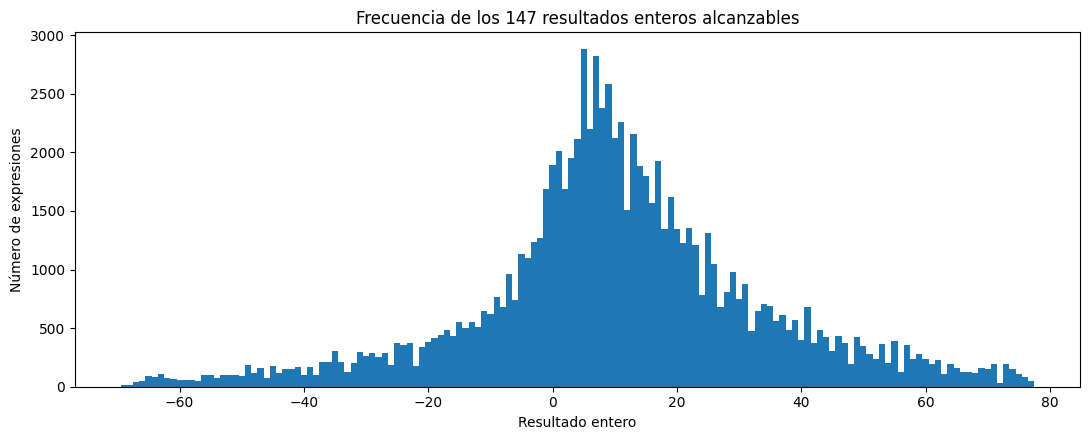

In [5]:
def fuerza_bruta(cifras=CIFRAS, operadores=OPERADORES):
    """Enumera todas las expresiones factibles y resume sus resultados."""
    total_expresiones = 0
    expresiones_enteras = 0
    frecuencias = Counter()
    ejemplos = {}

    minimo_global = None
    maximo_global = None
    expresion_minimo_global = None
    expresion_maximo_global = None

    inicio = time.perf_counter()

    for perm_cifras in permutations(cifras, len(operadores) + 1):
        for perm_operadores in permutations(operadores):
            total_expresiones += 1
            valor = evaluar_exacta(perm_cifras, perm_operadores)
            expresion = construir_expresion(perm_cifras, perm_operadores)

            if minimo_global is None or valor < minimo_global:
                minimo_global = valor
                expresion_minimo_global = expresion
            if maximo_global is None or valor > maximo_global:
                maximo_global = valor
                expresion_maximo_global = expresion

            if valor.denominator == 1:
                entero = valor.numerator
                expresiones_enteras += 1
                frecuencias[entero] += 1
                ejemplos.setdefault(entero, expresion)

    tiempo = time.perf_counter() - inicio
    valores_enteros = set(frecuencias)
    minimo_entero = min(valores_enteros)
    maximo_entero = max(valores_enteros)
    faltantes = sorted(set(range(minimo_entero, maximo_entero + 1)) - valores_enteros)

    return {
        'total_expresiones': total_expresiones,
        'expresiones_enteras': expresiones_enteras,
        'frecuencias': frecuencias,
        'ejemplos': ejemplos,
        'valores_enteros': valores_enteros,
        'minimo_entero': minimo_entero,
        'maximo_entero': maximo_entero,
        'faltantes': faltantes,
        'minimo_global': minimo_global,
        'maximo_global': maximo_global,
        'expresion_minimo_global': expresion_minimo_global,
        'expresion_maximo_global': expresion_maximo_global,
        'tiempo': tiempo,
    }


resultado_fb = fuerza_bruta()

print(f"Expresiones evaluadas:             {resultado_fb['total_expresiones']:,}")
print(f"Expresiones con resultado entero:  {resultado_fb['expresiones_enteras']:,}")
print(f"Enteros diferentes obtenidos:      {len(resultado_fb['valores_enteros'])}")
print(f"Mínimo entero:                     {resultado_fb['minimo_entero']}")
print(f"  Ejemplo: {resultado_fb['ejemplos'][resultado_fb['minimo_entero']]} = {resultado_fb['minimo_entero']}")
print(f"Máximo entero:                     {resultado_fb['maximo_entero']}")
print(f"  Ejemplo: {resultado_fb['ejemplos'][resultado_fb['maximo_entero']]} = {resultado_fb['maximo_entero']}")
print(f"Enteros ausentes entre ambos:      {resultado_fb['faltantes'] or 'ninguno'}")
print(f"Tiempo medido:                     {resultado_fb['tiempo']:.3f} s")

print('\nExtremos absolutos, incluidos resultados no enteros:')
print(
    f"  Mínimo global = {resultado_fb['minimo_global']} ≈ "
    f"{float(resultado_fb['minimo_global']):.6f}, con "
    f"{resultado_fb['expresion_minimo_global']}"
)
print(
    f"  Máximo global = {resultado_fb['maximo_global']} ≈ "
    f"{float(resultado_fb['maximo_global']):.6f}, con "
    f"{resultado_fb['expresion_maximo_global']}"
)

# Ejemplos solicitados y algunos valores intermedios.
valores_muestra = [-69, -50, -10, 0, 4, 25, 50, 77]
tabla_ejemplos = pd.DataFrame(
    {
        'Valor': valores_muestra,
        'Expresión de ejemplo': [resultado_fb['ejemplos'][v] for v in valores_muestra],
    }
)
display(tabla_ejemplos)

# Distribución de frecuencias de los resultados enteros.
xs = sorted(resultado_fb['frecuencias'])
ys = [resultado_fb['frecuencias'][x] for x in xs]
plt.figure(figsize=(11, 4.5))
plt.bar(xs, ys, width=1.0)
plt.xlabel('Resultado entero')
plt.ylabel('Número de expresiones')
plt.title('Frecuencia de los 147 resultados enteros alcanzables')
plt.tight_layout()
plt.show()

# Verificaciones automáticas de los resultados principales.
assert resultado_fb['total_expresiones'] == 362_880
assert resultado_fb['expresiones_enteras'] == 90_000
assert resultado_fb['minimo_entero'] == -69
assert resultado_fb['maximo_entero'] == 77
assert not resultado_fb['faltantes']


## 5. Complejidad del algoritmo por fuerza bruta

Calcule la complejidad del algoritmo por fuerza bruta.


### Respuesta

Sea `n` el número de cifras disponibles y `m` el número de operadores diferentes. Al usar todos los operadores se requieren `m+1` cifras.

El número de expresiones factibles es:

`P(n,m+1) · m! = [n! / (n-m-1)!] · m!`.

Evaluar una expresión necesita `m` operaciones aritméticas. Por tanto, la complejidad temporal es:

`Θ(P(n,m+1) · m! · m)`.

En el caso concreto `n=9` y `m=4`:

- `P(9,5) · 4! = 362 880` expresiones.
- Aproximadamente `362 880 · 4 = 1 451 520` operaciones aritméticas, además del coste de generar las permutaciones y construir las cadenas.

La memoria adicional es `O(|Z|)` si se guarda una expresión y una frecuencia por cada resultado entero distinto. En este problema `|Z|=147`. Si se almacenaran todas las expresiones, el consumo sería proporcional a `362 880`, pero el algoritmo implementado procesa cada expresión en flujo y no necesita hacerlo.


In [6]:
n = len(CIFRAS)
m = len(OPERADORES)
expresiones_teoricas = math.perm(n, m + 1) * math.factorial(m)
operaciones_teoricas = expresiones_teoricas * m

print(f'P({n},{m+1}) · {m}! = {expresiones_teoricas:,} expresiones')
print(f'Estimación aritmética: {operaciones_teoricas:,} operaciones elementales')
print(f'Memoria de resultados: {len(resultado_fb["valores_enteros"])} valores distintos')


P(9,5) · 4! = 362,880 expresiones
Estimación aritmética: 1,451,520 operaciones elementales
Memoria de resultados: 147 valores distintos


## 6. Algoritmo mejorado

**(*) Diseñe un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumente por qué mejora el algoritmo por fuerza bruta.**


### Respuesta

Se propone **programación dinámica con memorización de estados equivalentes**, una técnica coherente con las actividades guiadas del curso.

La expresión se procesa de izquierda a derecha sin construirla completamente. Para respetar la precedencia, cada estado contiene:

`(máscara_cifras, máscara_operadores, acumulado, término_actual)`

- `máscara_cifras`: cifras ya usadas.
- `máscara_operadores`: operadores ya usados.
- `acumulado`: suma de los términos ya cerrados por `+` o `-`.
- `término_actual`: cadena con signo de multiplicaciones y divisiones todavía no incorporada al acumulado.

Dos prefijos diferentes que hayan usado los mismos elementos y alcancen el mismo par `(acumulado, término_actual)` tendrán exactamente las mismas continuaciones posibles. Por ello, se conserva un único representante y se descartan duplicados mediante un diccionario.

La mejora no altera el conjunto de soluciones: únicamente fusiona caminos equivalentes. Además, utiliza `Fraction`, por lo que la comparación de estados y la identificación de enteros son exactas.

El algoritmo sigue siendo exponencial en el peor caso, pero evita la multiplicidad factorial de numerosos prefijos y reduce de forma significativa el número real de transiciones necesarias en esta instancia.


Estados únicos por nivel: [9, 252, 3796, 28116, 76670]
Transiciones por nivel:  [288, 5292, 45552, 140580]
Transiciones totales:    191,712
Estados finales únicos:  76,670
Tiempo medido:           0.586 s
Rango entero:            [-69, 77]
Valores ausentes:        ninguno

Verificación: ambos algoritmos producen los mismos resultados.


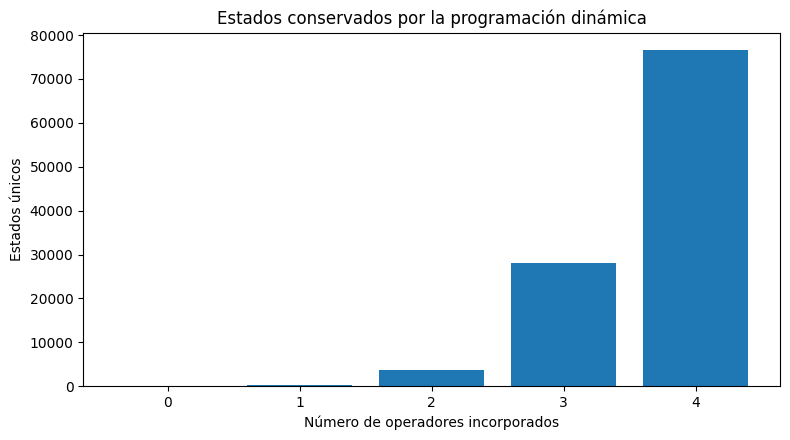

In [7]:
INDICE_OPERADOR = {operador: i for i, operador in enumerate(OPERADORES)}


def programacion_dinamica(cifras=CIFRAS, operadores=OPERADORES):
    """Construye estados únicos y conserva una expresión representativa."""
    # Estado inicial: una cifra usada, ningún operador, acumulado 0 y término positivo.
    nivel = {}
    for cifra in cifras:
        mascara_cifra = 1 << (cifra - 1)
        estado = (mascara_cifra, 0, Fraction(0, 1), Fraction(cifra, 1))
        nivel[estado] = str(cifra)

    estados_por_nivel = [len(nivel)]
    transiciones_por_nivel = []
    total_transiciones = 0
    inicio = time.perf_counter()

    for _ in range(len(operadores)):
        siguiente = {}
        transiciones_nivel = 0

        for (mask_cifras, mask_operadores, acumulado, termino), expresion in nivel.items():
            for operador in operadores:
                bit_operador = 1 << INDICE_OPERADOR[operador]
                if mask_operadores & bit_operador:
                    continue

                for cifra in cifras:
                    bit_cifra = 1 << (cifra - 1)
                    if mask_cifras & bit_cifra:
                        continue

                    transiciones_nivel += 1
                    if operador == '+':
                        nuevo_acumulado = acumulado + termino
                        nuevo_termino = Fraction(cifra, 1)
                    elif operador == '-':
                        nuevo_acumulado = acumulado + termino
                        nuevo_termino = Fraction(-cifra, 1)
                    elif operador == '*':
                        nuevo_acumulado = acumulado
                        nuevo_termino = termino * cifra
                    else:  # '/'
                        nuevo_acumulado = acumulado
                        nuevo_termino = termino / cifra

                    nuevo_estado = (
                        mask_cifras | bit_cifra,
                        mask_operadores | bit_operador,
                        nuevo_acumulado,
                        nuevo_termino,
                    )
                    siguiente.setdefault(nuevo_estado, expresion + operador + str(cifra))

        total_transiciones += transiciones_nivel
        transiciones_por_nivel.append(transiciones_nivel)
        nivel = siguiente
        estados_por_nivel.append(len(nivel))

    ejemplos = {}
    valores_enteros = set()
    minimo_global = None
    maximo_global = None
    expresion_minimo_global = None
    expresion_maximo_global = None

    for (_, _, acumulado, termino), expresion in nivel.items():
        valor = acumulado + termino
        if minimo_global is None or valor < minimo_global:
            minimo_global = valor
            expresion_minimo_global = expresion
        if maximo_global is None or valor > maximo_global:
            maximo_global = valor
            expresion_maximo_global = expresion
        if valor.denominator == 1:
            entero = valor.numerator
            valores_enteros.add(entero)
            ejemplos.setdefault(entero, expresion)

    tiempo = time.perf_counter() - inicio
    minimo_entero = min(valores_enteros)
    maximo_entero = max(valores_enteros)
    faltantes = sorted(set(range(minimo_entero, maximo_entero + 1)) - valores_enteros)

    return {
        'estados_por_nivel': estados_por_nivel,
        'transiciones_por_nivel': transiciones_por_nivel,
        'total_transiciones': total_transiciones,
        'estados_finales': len(nivel),
        'valores_enteros': valores_enteros,
        'ejemplos': ejemplos,
        'minimo_entero': minimo_entero,
        'maximo_entero': maximo_entero,
        'faltantes': faltantes,
        'minimo_global': minimo_global,
        'maximo_global': maximo_global,
        'expresion_minimo_global': expresion_minimo_global,
        'expresion_maximo_global': expresion_maximo_global,
        'tiempo': tiempo,
    }


resultado_dp = programacion_dinamica()

print('Estados únicos por nivel:', resultado_dp['estados_por_nivel'])
print('Transiciones por nivel: ', resultado_dp['transiciones_por_nivel'])
print(f"Transiciones totales:    {resultado_dp['total_transiciones']:,}")
print(f"Estados finales únicos:  {resultado_dp['estados_finales']:,}")
print(f"Tiempo medido:           {resultado_dp['tiempo']:.3f} s")
print(f"Rango entero:            [{resultado_dp['minimo_entero']}, {resultado_dp['maximo_entero']}]")
print(f"Valores ausentes:        {resultado_dp['faltantes'] or 'ninguno'}")

# La programación dinámica debe producir exactamente el mismo conjunto de enteros.
assert resultado_dp['valores_enteros'] == resultado_fb['valores_enteros']
assert resultado_dp['minimo_global'] == resultado_fb['minimo_global']
assert resultado_dp['maximo_global'] == resultado_fb['maximo_global']
print('\nVerificación: ambos algoritmos producen los mismos resultados.')

# Visualización del crecimiento de estados únicos.
plt.figure(figsize=(8, 4.5))
plt.bar(range(len(resultado_dp['estados_por_nivel'])), resultado_dp['estados_por_nivel'])
plt.xticks(range(len(resultado_dp['estados_por_nivel'])))
plt.xlabel('Número de operadores incorporados')
plt.ylabel('Estados únicos')
plt.title('Estados conservados por la programación dinámica')
plt.tight_layout()
plt.show()


## 7. Complejidad del algoritmo mejorado

**(*) Calcule la complejidad del algoritmo.**


### Respuesta

Sea `S_l` el número de estados distintos después de incorporar `l` operadores. Cada estado de ese nivel puede expandirse, como máximo, con:

`(m-l) · (n-l-1)` pares operador-cifra.

Por tanto, la complejidad temporal puede expresarse de forma dependiente de los estados realmente diferentes:

`O( Σ S_l · (m-l) · (n-l-1) )`, para `l = 0, ..., m-1`.

La complejidad espacial es:

`O(max S_l)`, porque solo se conservan el nivel actual y el siguiente.

El número de valores racionales diferentes que pueden aparecer hace que el peor caso continúe siendo exponencial; no se afirma que el problema pase a ser polinómico. La mejora consiste en no volver a explorar continuaciones idénticas de estados equivalentes.

Para esta instancia:

- Fuerza bruta: 362 880 expresiones completas y unas 1 451 520 operaciones aritméticas.
- Programación dinámica: 191 712 transiciones y 76 670 evaluaciones finales.
- Estados únicos por nivel: `[9, 252, 3796, 28116, 76670]`.

La reducción concreta se calcula en la celda siguiente. Los tiempos son mediciones orientativas y dependen del equipo y del entorno de ejecución.


In [8]:
operaciones_fb = resultado_fb['total_expresiones'] * len(OPERADORES)
operaciones_dp_aprox = resultado_dp['total_transiciones'] + resultado_dp['estados_finales']
reduccion_operaciones = 100 * (1 - operaciones_dp_aprox / operaciones_fb)
reduccion_finales = 100 * (1 - resultado_dp['estados_finales'] / resultado_fb['total_expresiones'])
aceleracion_medida = resultado_fb['tiempo'] / resultado_dp['tiempo'] if resultado_dp['tiempo'] else float('inf')

comparacion = pd.DataFrame(
    [
        {
            'Método': 'Fuerza bruta',
            'Candidatos/estados finales': resultado_fb['total_expresiones'],
            'Operaciones o transiciones aproximadas': operaciones_fb,
            'Tiempo medido (s)': resultado_fb['tiempo'],
        },
        {
            'Método': 'Programación dinámica',
            'Candidatos/estados finales': resultado_dp['estados_finales'],
            'Operaciones o transiciones aproximadas': operaciones_dp_aprox,
            'Tiempo medido (s)': resultado_dp['tiempo'],
        },
    ]
)
display(comparacion.style.format({'Tiempo medido (s)': '{:.3f}'}))

print(f'Reducción aproximada de operaciones/transiciones: {reduccion_operaciones:.2f}%')
print(f'Reducción de estados finales:                     {reduccion_finales:.2f}%')
print(f'Aceleración observada en esta ejecución:           {aceleracion_medida:.2f} veces')


,Método,Candidatos/estados finales,Operaciones o transiciones aproximadas,Tiempo medido (s)
0,Fuerza bruta,362880,1451520,2.403
1,Programación dinámica,76670,268382,0.586


Reducción aproximada de operaciones/transiciones: 81.51%
Reducción de estados finales:                     78.87%
Aceleración observada en esta ejecución:           4.10 veces


## 8. Juego de datos de entrada aleatorios

Según el problema y cuando tenga sentido, diseñe un juego de datos de entrada aleatorios.


### Respuesta

El conjunto de cifras y operadores del problema es fijo. Por ello, el dato de entrada más natural es la **cantidad objetivo** que se desea obtener.

Se genera un conjunto reproducible de objetivos enteros aleatorios dentro del intervalo `[-69,77]`. También se incluyen casos de control:

- los extremos enteros `-69` y `77`;
- `-70` y `78`, que están comprendidos entre los extremos racionales absolutos pero no son resultados enteros alcanzables;
- `100`, claramente fuera del rango.

Se fija una semilla para que cualquier persona que ejecute el Notebook obtenga el mismo juego de prueba.


In [9]:
SEMILLA = 2026
random.seed(SEMILLA)

objetivos_aleatorios = random.sample(
    range(resultado_dp['minimo_entero'], resultado_dp['maximo_entero'] + 1),
    10,
)
casos_control = [
    resultado_dp['minimo_entero'],
    resultado_dp['maximo_entero'],
    -70,
    78,
    100,
]

datos_entrada = list(dict.fromkeys(objetivos_aleatorios + casos_control))

print('Semilla:', SEMILLA)
print('Objetivos generados:', datos_entrada)


Semilla: 2026
Objetivos generados: [-39, 12, 59, 62, -43, -12, 73, 38, 77, 71, -69, -70, 78, 100]


## 9. Aplicación al juego de datos generado

Aplique el algoritmo al juego de datos generado.


### Respuesta

Se utiliza el diccionario generado por programación dinámica. Consultar un objetivo después del preprocesamiento tiene coste promedio `O(1)`:

- si el objetivo existe, se devuelve una expresión válida;
- si no existe, se informa que no es alcanzable bajo las restricciones.

Cada expresión devuelta vuelve a evaluarse exactamente como comprobación automática.


In [10]:
def resolver_objetivos(objetivos, resultado):
    filas = []
    for objetivo in objetivos:
        expresion = resultado['ejemplos'].get(objetivo)
        if expresion is None:
            filas.append(
                {
                    'Objetivo': objetivo,
                    '¿Alcanzable?': 'No',
                    'Expresión': '-',
                    'Verificación exacta': '-',
                }
            )
        else:
            verificacion = evaluar_cadena_exacta(expresion)
            assert verificacion == objetivo
            filas.append(
                {
                    'Objetivo': objetivo,
                    '¿Alcanzable?': 'Sí',
                    'Expresión': expresion,
                    'Verificación exacta': str(verificacion),
                }
            )
    return pd.DataFrame(filas)


tabla_pruebas = resolver_objetivos(datos_entrada, resultado_dp)
display(tabla_pruebas)

alcanzables = (tabla_pruebas['¿Alcanzable?'] == 'Sí').sum()
print(f'Casos alcanzables: {alcanzables} de {len(tabla_pruebas)}')


,Objetivo,¿Alcanzable?,Expresión,Verificación exacta
0,-39,Sí,1+4/2-6*7,-39
1,12,Sí,1+2*7-9/3,12
2,59,Sí,2+7*9-6/1,59
3,62,Sí,1+7*9-4/2,62
4,-43,Sí,2+3-6*8/1,-43
5,-12,Sí,1+2-5*9/3,-12
6,73,Sí,3+8*9-2/1,73
7,38,Sí,1+5*8-6/2,38
8,77,Sí,7+8*9-2/1,77
9,71,Sí,1+8*9-4/2,71


Casos alcanzables: 11 de 14


## 10. Referencias

Enumere las referencias utilizadas, si ha sido necesario, para llevar a cabo el trabajo.


### Respuesta

1. Universidad Internacional de Valencia. *VC4 - Problemas del Trabajo Práctico. 03MIAR - Algoritmos de optimización*. Enunciado del Problema 3 y requisitos del entregable.
2. Universidad Internacional de Valencia. *Seminario_Algoritmos.ipynb*. Plantilla oficial del trabajo práctico.
3. Materiales de las Actividades Guiadas 1 a 4 de la asignatura: divide y vencerás, vuelta atrás, programación dinámica, ramificación y poda, búsqueda aleatoria, búsqueda local, recocido simulado, colonia de hormigas y algoritmos genéticos.
4. Python Software Foundation. *itertools - Functions creating iterators for efficient looping*. Documentación de `itertools.permutations`.
5. Python Software Foundation. *fractions - Rational numbers*. Documentación de `fractions.Fraction`.
6. Brassard, G. y Bratley, P. (1997). *Fundamentos de algoritmia*. Prentice Hall.
7. Guerequeta, R. y Vallecillo, A. (2000). *Técnicas de diseño de algoritmos*.

El código del trabajo es autocontenido y no depende de servicios externos ni de conjuntos de datos descargados de Internet.


## 11. Líneas futuras

Describa brevemente cómo es posible avanzar en el estudio del problema. Considere variaciones del problema y aumentos de tamaño.


### Respuesta y conclusiones

El estudio puede ampliarse en varias direcciones:

- aumentar el número de cifras y operadores;
- admitir paréntesis, concatenación, potencias, raíces u operadores repetidos;
- buscar únicamente una expresión para un objetivo concreto mediante vuelta atrás, ramificación y poda, A* o búsqueda bidireccional;
- utilizar una estrategia *meet-in-the-middle* para combinar resultados parciales;
- paralelizar la evaluación de permutaciones;
- formular el problema con programación por restricciones o SAT/SMT;
- comparar algoritmos exactos con búsqueda local, recocido simulado o algoritmos genéticos cuando el espacio sea demasiado grande para enumerarlo completamente;
- estudiar no solo la factibilidad, sino el número de expresiones por valor, la longitud mínima de una expresión o criterios de legibilidad.

## Conclusión principal

Bajo la interpretación oficial adoptada, existen `362 880` expresiones factibles. De ellas, `90 000` producen un resultado entero y generan exactamente `147` enteros distintos. Los extremos **enteros** son `-69` y `77`, y se obtiene cada entero del intervalo completo `[-69,77]`.

Los extremos absolutos, permitiendo resultados no enteros, son `-495/7 ≈ -70,714286` y `473/6 ≈ 78,833333`. Por ello, si se interpretara literalmente el intervalo entre los extremos racionales, los enteros `-70` y `78` no serían alcanzables. La formulación del enunciado se centra, sin embargo, en los valores enteros posibles, cuyo conjunto es exactamente `{-69, -68, ..., 76, 77}`.

La programación dinámica produce los mismos resultados que la fuerza bruta, pero fusiona estados equivalentes y reduce significativamente el trabajo computacional sin sacrificar exactitud.
